In [39]:
import pandas as pd
import numpy as np

from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 50)


In [6]:
df_holidays = pd.read_csv("/Users/mns/Documents/UMD/Fall 2025/MSML610/Project/store-sales-time-series-forecasting/holidays_events.csv")
df_oil = pd.read_csv("/Users/mns/Documents/UMD/Fall 2025/MSML610/Project/store-sales-time-series-forecasting/oil.csv")
df_stores = pd.read_csv("/Users/mns/Documents/UMD/Fall 2025/MSML610/Project/store-sales-time-series-forecasting/stores.csv")
df_transactions = pd.read_csv("/Users/mns/Documents/UMD/Fall 2025/MSML610/Project/store-sales-time-series-forecasting/transactions.csv")
df_train = pd.read_csv("/Users/mns/Documents/umd_classes/class_project/MSML610/Fall2025/Project/store-sales-time-series-forecasting/train.csv")
df_test = pd.read_csv("/Users/mns/Documents/umd_classes/class_project/MSML610/Fall2025/Project/store-sales-time-series-forecasting/test.csv")

In [5]:
df_train

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,1,2013-01-01,1,BABY CARE,0.000,0
2,2,2013-01-01,1,BEAUTY,0.000,0
3,3,2013-01-01,1,BEVERAGES,0.000,0
4,4,2013-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


In [7]:
df_test

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0
...,...,...,...,...,...
28507,3029395,2017-08-31,9,POULTRY,1
28508,3029396,2017-08-31,9,PREPARED FOODS,0
28509,3029397,2017-08-31,9,PRODUCE,1
28510,3029398,2017-08-31,9,SCHOOL AND OFFICE SUPPLIES,9


In [5]:
df_holidays

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
...,...,...,...,...,...,...
345,2017-12-22,Additional,National,Ecuador,Navidad-3,False
346,2017-12-23,Additional,National,Ecuador,Navidad-2,False
347,2017-12-24,Additional,National,Ecuador,Navidad-1,False
348,2017-12-25,Holiday,National,Ecuador,Navidad,False


### Exploratory Data Analysis Roadmap
- Inventory each Kaggle CSV (sales, transactions, oil prices, holidays) before preprocessing.
- Summarize row counts, date coverage, and missing values to understand data quality.
- Join the tables on shared keys `(date, store_nbr, family)` to validate relational integrity.
- Plot core trends (overall sales, per-store/family behavior, effect of holidays/promotions) to motivate downstream features.
- Keep EDA code modular so it can be reused inside the tutorial notebooks later.


In [13]:
# Adjust this path if you move the Kaggle export locally.
DATA_ROOT = Path('//Users/mns/Documents/umd_classes/class_project/MSML610/Fall2025/Project/store-sales-time-series-forecasting')

CSV_PATHS = {
    'sales': DATA_ROOT / 'train.csv',
    'test': DATA_ROOT / 'test.csv',
    'transactions': DATA_ROOT / 'transactions.csv',
    'holidays': DATA_ROOT / 'holidays_events.csv',
    'oil': DATA_ROOT / 'oil.csv',
}

DATE_COLUMNS = {
    'sales': ['date'],
    'test': ['date'],
    'transactions': ['date'],
    'holidays': ['date'],
    'oil': ['date'],
}
CSV_PATHS


{'sales': PosixPath('//Users/mns/Documents/umd_classes/class_project/MSML610/Fall2025/Project/store-sales-time-series-forecasting/train.csv'),
 'test': PosixPath('//Users/mns/Documents/umd_classes/class_project/MSML610/Fall2025/Project/store-sales-time-series-forecasting/test.csv'),
 'transactions': PosixPath('//Users/mns/Documents/umd_classes/class_project/MSML610/Fall2025/Project/store-sales-time-series-forecasting/transactions.csv'),
 'holidays': PosixPath('//Users/mns/Documents/umd_classes/class_project/MSML610/Fall2025/Project/store-sales-time-series-forecasting/holidays_events.csv'),
 'oil': PosixPath('//Users/mns/Documents/umd_classes/class_project/MSML610/Fall2025/Project/store-sales-time-series-forecasting/oil.csv')}

In [14]:
data_frames = {}
for name, path in CSV_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing expected file: {path}")
    frame = pd.read_csv(path)
    for date_col in DATE_COLUMNS.get(name, []):
        frame[date_col] = pd.to_datetime(frame[date_col])
    data_frames[name] = frame

sales = data_frames['sales']
transactions = data_frames['transactions']
holidays = data_frames['holidays']
oil = data_frames['oil']
len(data_frames)


5

In [15]:
summary_rows = []
for name, frame in data_frames.items():
    date_cols = DATE_COLUMNS.get(name, [])
    if date_cols:
        date_range = f"{frame[date_cols[0]].min():%Y-%m-%d} -> {frame[date_cols[0]].max():%Y-%m-%d}"
    else:
        date_range = 'n/a'
    summary_rows.append({
        'dataset': name,
        'rows': frame.shape[0],
        'columns': frame.shape[1],
        'date_range': date_range,
    })
summary_df = pd.DataFrame(summary_rows).sort_values('dataset')
summary_df


,dataset,rows,columns,date_range
3,holidays,350,6,2012-03-02 -> 2017-12-26
4,oil,1218,2,2013-01-01 -> 2017-08-31
0,sales,3000888,6,2013-01-01 -> 2017-08-15
1,test,28512,5,2017-08-16 -> 2017-08-31
2,transactions,83488,3,2013-01-01 -> 2017-08-15


In [16]:
missing_report = (
    pd.concat({name: frame.isna().sum() for name, frame in data_frames.items()}, axis=1)
    .rename_axis('column')
    .reset_index()
)
missing_report


,column,sales,test,transactions,holidays,oil
0,id,0.0,0.0,NaN,NaN,NaN
1,date,0.0,0.0,0.0,0.0,0.0
2,store_nbr,0.0,0.0,0.0,NaN,NaN
3,family,0.0,0.0,NaN,NaN,NaN
4,sales,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
8,locale,NaN,NaN,NaN,0.0,NaN
9,locale_name,NaN,NaN,NaN,0.0,NaN
10,description,NaN,NaN,NaN,0.0,NaN
11,transferred,NaN,NaN,NaN,0.0,NaN


In [17]:
merged_sample = (
    sales
    .merge(transactions[['date','store_nbr','transactions']], on=['date','store_nbr'], how='left')
    .merge(oil, on='date', how='left')
    .merge(
        holidays[['date','type','locale','locale_name','description','transferred']],
        on='date',
        how='left'
    )
)
merged_sample.head()


,id,date,store_nbr,family,sales,onpromotion,transactions,dcoilwtico,type,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1,1,2013-01-01,1,BABY CARE,0.0,0,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
2,2,2013-01-01,1,BEAUTY,0.0,0,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
4,4,2013-01-01,1,BOOKS,0.0,0,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False


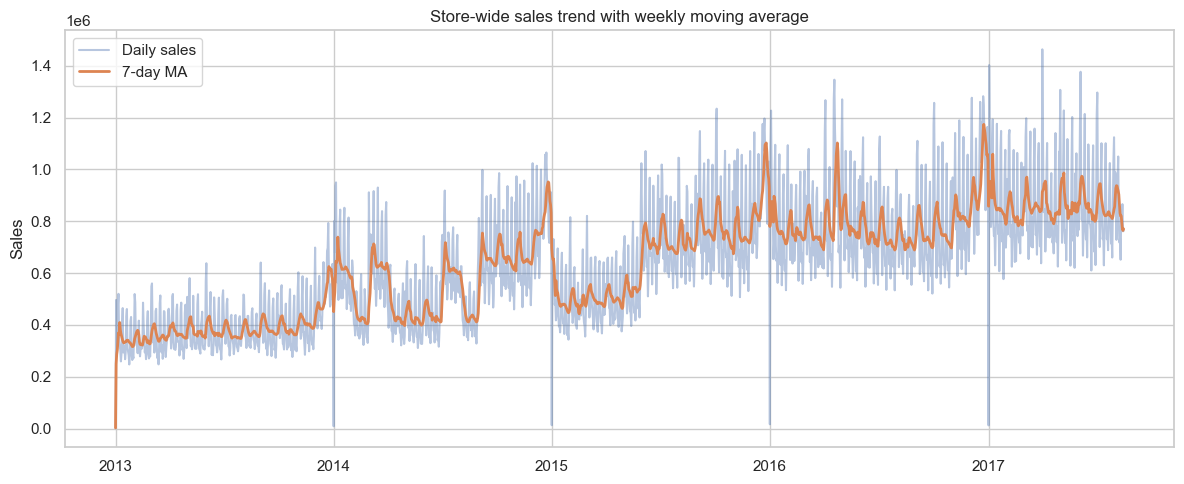

In [18]:
daily_sales = sales.groupby('date').agg(
    total_sales=('sales','sum'),
    promo_sales=('onpromotion','sum'),
)
daily_sales['sales_7d_ma'] = daily_sales['total_sales'].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(daily_sales.index, daily_sales['total_sales'], label='Daily sales', alpha=0.4)
ax.plot(daily_sales.index, daily_sales['sales_7d_ma'], label='7-day MA', linewidth=2)
ax.set_title('Store-wide sales trend with weekly moving average')
ax.set_ylabel('Sales')
ax.legend()
plt.tight_layout()
plt.show()


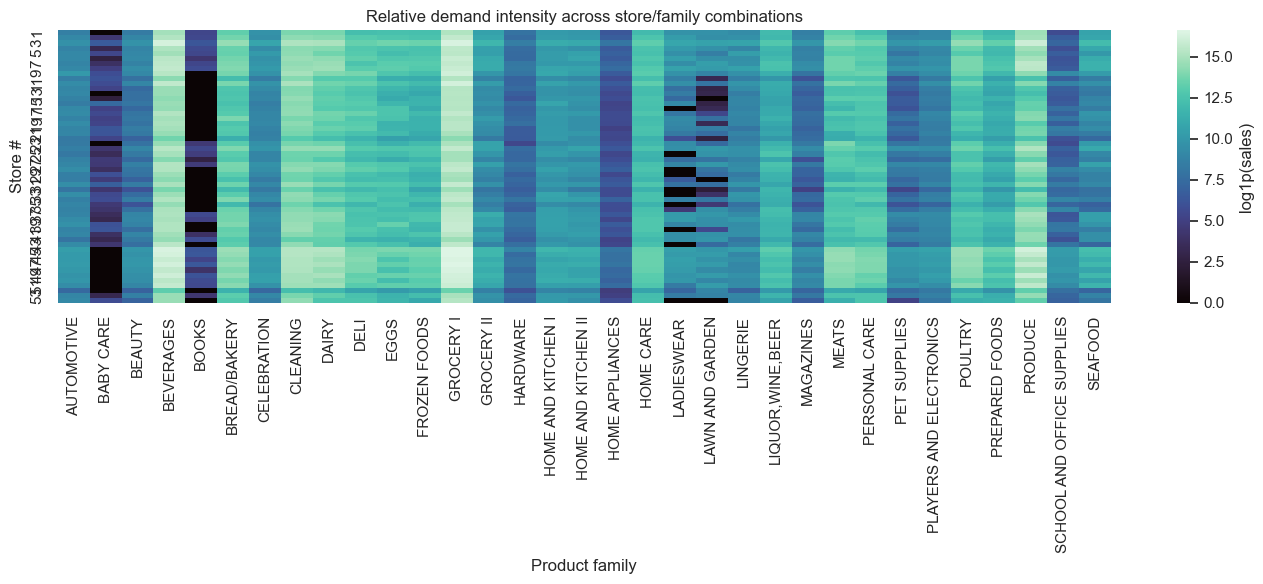

In [ ]:
store_family_pivot = (
    sales.groupby(['store_nbr', 'family'])['sales'].sum().unstack(fill_value=0)
)
plt.figure(figsize=(16, 10))
sns.heatmap(
    np.log1p(store_family_pivot),
    cmap='mako',
    cbar_kws={'label': 'log1p(sales)'},
    xticklabels=True,
    yticklabels=False,
)
plt.title('Relative demand intensity across store/family combinations')
plt.xlabel('Product family')
plt.ylabel('Store #')
y_ticks = np.arange(len(store_family_pivot.index)) + 0.5
plt.yticks(y_ticks[::2], store_family_pivot.index[::2], rotation=0, fontsize=7)
plt.tight_layout()
plt.show()


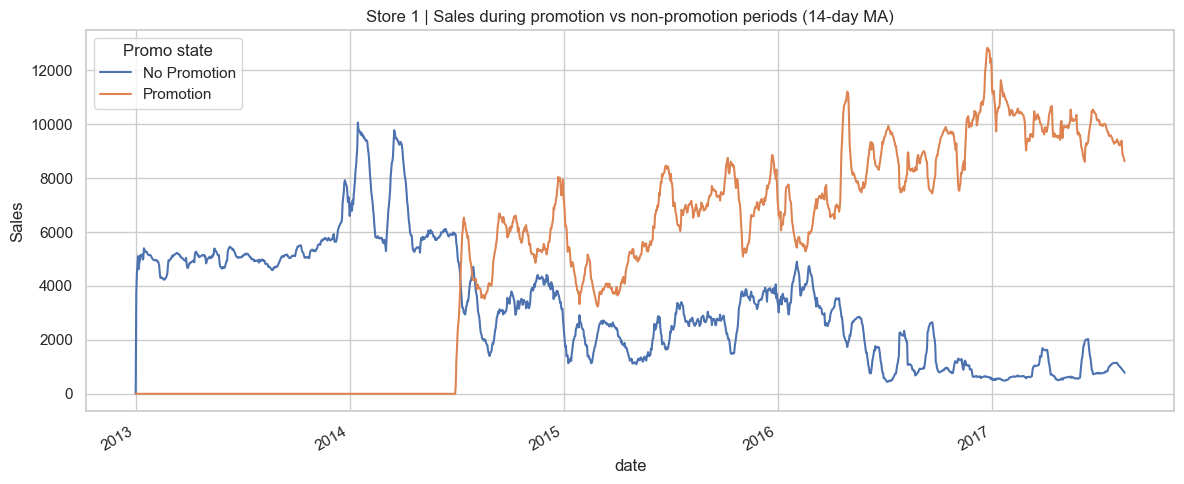

In [30]:
FOCUS_STORE = int(sales['store_nbr'].value_counts().idxmax())
focus_sales = sales[sales['store_nbr'] == FOCUS_STORE].copy()
focus_sales['promo_state'] = np.where(focus_sales['onpromotion'] > 0, 'Promotion', 'No Promotion')

promo_series = (
    focus_sales.groupby(['date', 'promo_state'])['sales'].sum().reset_index()
)

promo_pivot = promo_series.pivot(index='date', columns='promo_state', values='sales').fillna(0)
promo_smoothed = promo_pivot.rolling(14, min_periods=1).mean()

ax = promo_smoothed.plot(figsize=(12, 5))
ax.set_title(f'Store {FOCUS_STORE} | Sales during promotion vs non-promotion periods (14-day MA)')
ax.set_ylabel('Sales')
ax.legend(title='Promo state')
plt.tight_layout()
plt.show()


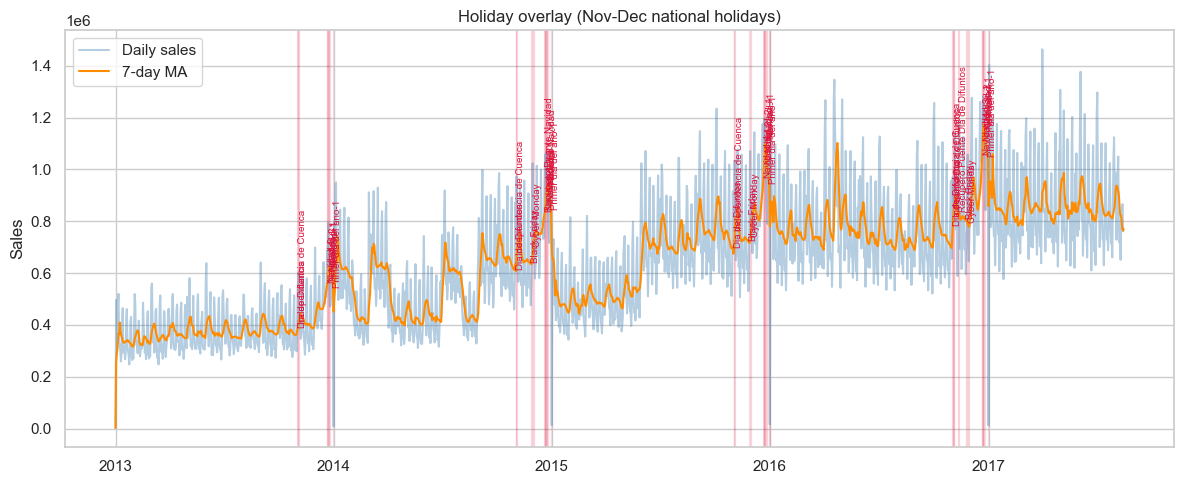

In [31]:
national_holidays = holidays[holidays['locale'] == 'National'].copy()
holiday_focus = national_holidays[national_holidays['date'].dt.month.isin([11, 12])]

holiday_sales = daily_sales.reset_index().merge(
    holiday_focus[['date', 'description']].drop_duplicates('date'),
    on='date',
    how='left',
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(holiday_sales['date'], holiday_sales['total_sales'], color='steelblue', alpha=0.4, label='Daily sales')
ax.plot(holiday_sales['date'], holiday_sales['sales_7d_ma'], color='darkorange', label='7-day MA')

for _, row in holiday_sales.dropna(subset=['description']).iterrows():
    ax.axvspan(row['date'] - pd.Timedelta(days=0.5), row['date'] + pd.Timedelta(days=0.5), color='crimson', alpha=0.12)
    ax.text(row['date'], row['sales_7d_ma'] * 1.02, row['description'], rotation=90, fontsize=7, color='crimson')

ax.set_title('Holiday overlay (Nov-Dec national holidays)')
ax.set_ylabel('Sales')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


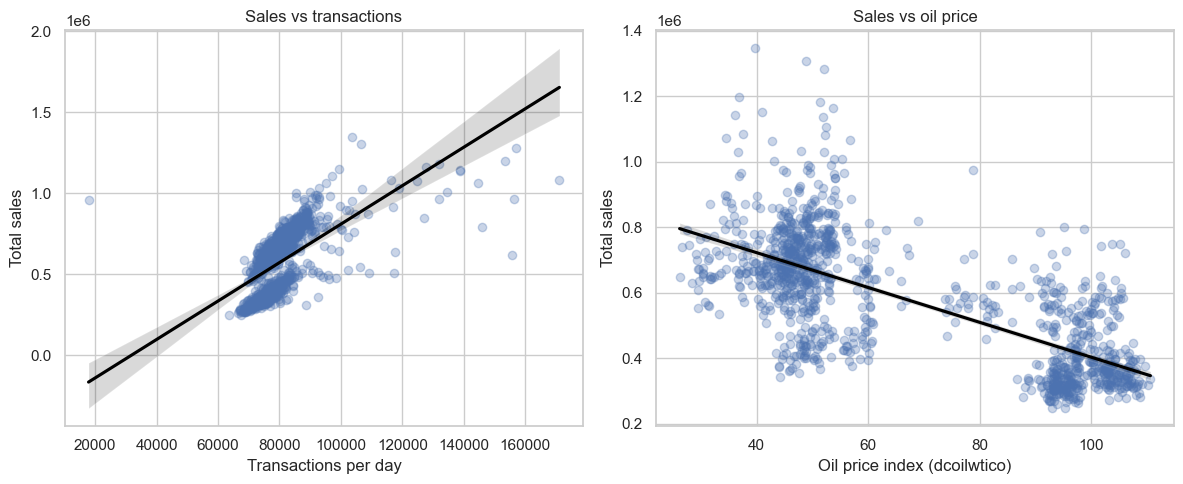

In [32]:
daily_transactions = transactions.groupby('date')['transactions'].sum().rename('transactions_total')
oil_daily = oil[['date', 'dcoilwtico']].rename(columns={'dcoilwtico': 'oil_price'})

daily_regressors = (
    daily_sales[['total_sales']]
    .merge(daily_transactions, left_index=True, right_index=True, how='left')
    .reset_index()
    .merge(oil_daily, on='date', how='left')
    .dropna(subset=['transactions_total', 'oil_price'])
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(ax=axes[0], data=daily_regressors, x='transactions_total', y='total_sales', scatter_kws={'alpha': 0.3}, line_kws={'color': 'black'})
axes[0].set_title('Sales vs transactions')
axes[0].set_xlabel('Transactions per day')
axes[0].set_ylabel('Total sales')

sns.regplot(ax=axes[1], data=daily_regressors, x='oil_price', y='total_sales', scatter_kws={'alpha': 0.3}, line_kws={'color': 'black'})
axes[1].set_title('Sales vs oil price')
axes[1].set_xlabel('Oil price index (dcoilwtico)')
axes[1].set_ylabel('Total sales')

plt.tight_layout()
plt.show()


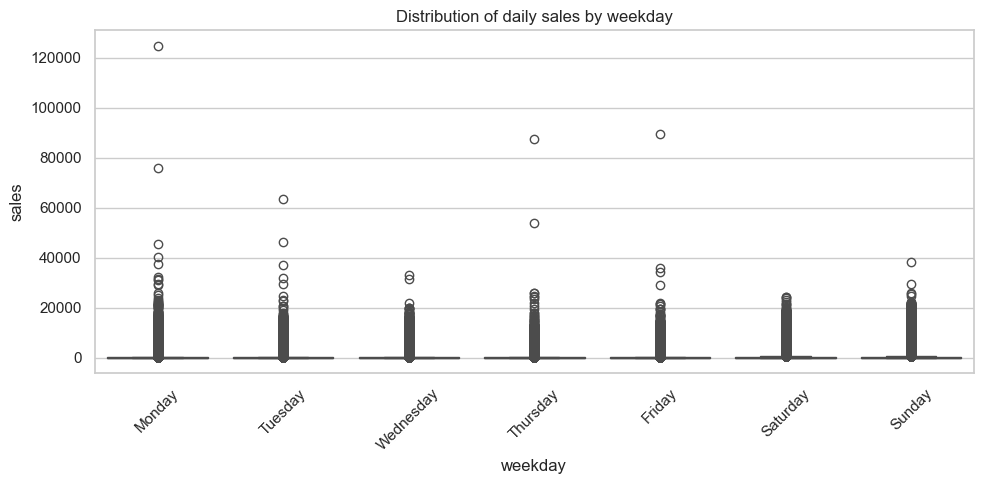

is_weekend
Weekday    321.629081
Weekend    448.179995
Name: sales, dtype: float64

In [33]:
sales['weekday'] = sales['date'].dt.day_name()
sales['is_weekend'] = sales['date'].dt.dayofweek >= 5

weekday_summary = sales.groupby(['weekday', 'is_weekend'])['sales'].mean().reset_index()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
sns.boxplot(data=sales, x='weekday', y='sales', order=weekday_order)
plt.title('Distribution of daily sales by weekday')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df_weekend = sales.groupby('is_weekend')['sales'].mean().rename({False: 'Weekday', True: 'Weekend'})
df_weekend


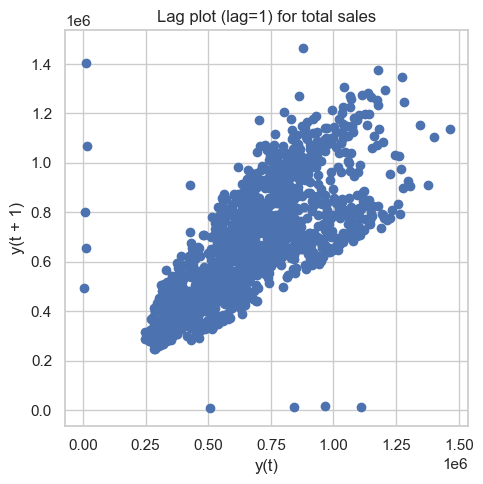

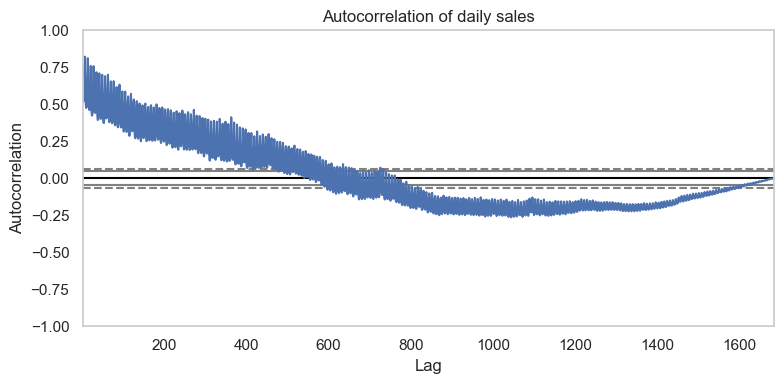

In [34]:
from pandas.plotting import lag_plot, autocorrelation_plot

plt.figure(figsize=(5, 5))
lag_plot(daily_sales['total_sales'])
plt.title('Lag plot (lag=1) for total sales')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
autocorrelation_plot(daily_sales['total_sales'])
plt.title('Autocorrelation of daily sales')
plt.tight_layout()
plt.show()


**Next EDA Ideas**
- Repeat the weekday/promotion analysis for specific product families to expose anomalies.
- Explore rolling-window statistics (variance, coefficient of variation) per store to detect volatility.
- Prototype feature importance via tree-based baselines to sanity-check engineered signals.


## Data Preprocessing Pipeline
Following the project instructions, we now clean+aggregate the raw tables, engineer temporal/event features, and build supervised learning windows for the downstream LSTM.


In [35]:
ID_COLUMNS = ['store_nbr', 'family']
DATE_COLUMN = 'date'
TARGET_COLUMN = 'sales'
LOOKBACK_DAYS = 120
HORIZON_DAYS = 28

# Define helper dictionaries for feature engineering.
HOLIDAY_COLUMNS = ['date', 'type', 'locale', 'locale_name', 'description', 'transferred']
TRANSACTION_COLUMNS = ['date', 'store_nbr', 'transactions']


In [36]:
def build_base_table(sales_df, transactions_df, oil_df, holidays_df):
    """Return a daily store/family table augmented with auxiliary signals."""
    sales_clean = sales_df.copy()
    sales_clean['family'] = (
        sales_clean['family'].str.strip().str.lower().str.replace(' ', '_')
    )
    grouped = (
        sales_clean.groupby([DATE_COLUMN] + ID_COLUMNS, as_index=False)
        .agg({TARGET_COLUMN: 'sum', 'onpromotion': 'sum'})
    )

    base = grouped.merge(transactions_df[TRANSACTION_COLUMNS], on=['date', 'store_nbr'], how='left')
    base = base.merge(oil_df[['date', 'dcoilwtico']], on='date', how='left')
    base = base.merge(holidays_df[HOLIDAY_COLUMNS], on='date', how='left')

    base['is_holiday'] = np.where(base['description'].notna(), 1, 0)
    base['is_transferred_holiday'] = np.where(base['transferred'] == True, 1, 0)
    base['transactions'] = base['transactions'].fillna(0)
    base['dcoilwtico'] = base['dcoilwtico'].ffill().bfill()
    return base.sort_values(['store_nbr', 'family', 'date'])

def add_temporal_features(frame):
    frame = frame.copy()
    frame['day_of_week'] = frame['date'].dt.dayofweek
    frame['week_of_year'] = frame['date'].dt.isocalendar().week.astype(int)
    frame['month'] = frame['date'].dt.month
    frame['year'] = frame['date'].dt.year

    frame['dow_sin'] = np.sin(2 * np.pi * frame['day_of_week'] / 7)
    frame['dow_cos'] = np.cos(2 * np.pi * frame['day_of_week'] / 7)
    frame['month_sin'] = np.sin(2 * np.pi * frame['month'] / 12)
    frame['month_cos'] = np.cos(2 * np.pi * frame['month'] / 12)
    frame['week_sin'] = np.sin(2 * np.pi * frame['week_of_year'] / 52)
    frame['week_cos'] = np.cos(2 * np.pi * frame['week_of_year'] / 52)
    return frame

def scale_features(frame, feature_columns):
    scaler = StandardScaler()
    frame[feature_columns] = scaler.fit_transform(frame[feature_columns])
    return frame, scaler

def make_windows(group_df, feature_columns, target_column, lookback, horizon):
    group_df = group_df.sort_values(DATE_COLUMN)
    feature_array = group_df[feature_columns].to_numpy()
    target_array = group_df[target_column].to_numpy()
    dates = group_df[DATE_COLUMN].to_numpy()

    windows_x, windows_y, windows_meta = [], [], []
    total_steps = len(group_df)
    for start in range(0, total_steps - lookback - horizon + 1):
        end = start + lookback
        target_end = end + horizon
        windows_x.append(feature_array[start:end])
        windows_y.append(target_array[end:target_end])
        windows_meta.append(
            {
                'store_nbr': group_df['store_nbr'].iloc[0],
                'family': group_df['family'].iloc[0],
                'window_start': dates[start],
                'prediction_start': dates[end],
            }
        )
    return windows_x, windows_y, windows_meta


In [40]:
base_table = build_base_table(sales, transactions, oil, holidays)
base_table = add_temporal_features(base_table)
base_table['log_sales'] = np.log1p(base_table['sales'])

feature_columns = [
    'onpromotion',
    'transactions',
    'dcoilwtico',
    'is_holiday',
    'is_transferred_holiday',
    'dow_sin', 'dow_cos',
    'week_sin', 'week_cos',
    'month_sin', 'month_cos',
]

base_table, feature_scaler = scale_features(base_table, feature_columns)
base_table[['log_sales']] = StandardScaler().fit_transform(base_table[['log_sales']])
base_table = base_table.fillna(0)
base_table.head()


,date,store_nbr,family,sales,onpromotion,transactions,dcoilwtico,type,locale,locale_name,description,transferred,is_holiday,is_transferred_holiday,day_of_week,week_of_year,month,year,dow_sin,dow_cos,month_sin,month_cos,week_sin,week_cos,log_sales
0,2013-01-01,1,automotive,0.0,-0.213586,-1.503816,0.985067,Holiday,National,Ecuador,Primer dia del ano,False,2.253445,-0.072654,1,1,1,2013,1.106573,0.881543,0.650526,1.288908,0.087133,1.435056,-1.087066
1782,2013-01-02,1,automotive,2.0,-0.213586,0.532910,0.985067,NaN,NaN,NaN,NaN,NaN,-0.443765,-0.072654,2,1,1,2013,1.379462,-0.315733,0.650526,1.288908,0.087133,1.435056,-0.679499
3564,2013-01-03,1,automotive,3.0,-0.213586,0.264692,0.978443,NaN,NaN,NaN,NaN,NaN,-0.443765,-0.072654,3,1,1,2013,0.614842,-1.275873,0.650526,1.288908,0.087133,1.435056,-0.572773
5346,2013-01-04,1,automotive,3.0,-0.213586,0.293636,0.984288,NaN,NaN,NaN,NaN,NaN,-0.443765,-0.072654,4,1,1,2013,-0.611513,-1.275873,0.650526,1.288908,0.087133,1.435056,-0.572773
7128,2013-01-05,1,automotive,5.0,-0.213586,-0.047909,0.984288,Work Day,National,Ecuador,Recupero puente Navidad,False,2.253445,-0.072654,5,1,1,2013,-1.376133,-0.315733,0.650526,1.288908,0.087133,1.435056,-0.422353


In [31]:
clean_table = base_table.dropna()
all_inputs, all_targets, metadata_rows = [], [], []
for (store, family), group in clean_table.groupby(ID_COLUMNS):
    x, y, meta = make_windows(group, feature_columns, 'log_sales', LOOKBACK_DAYS, HORIZON_DAYS)
    all_inputs.extend(x)
    all_targets.extend(y)
    metadata_rows.extend(meta)

inputs = np.array(all_inputs)
targets = np.array(all_targets)
metadata_df = pd.DataFrame(metadata_rows)
inputs.shape, targets.shape, metadata_df.head()


((240570, 120, 11),
 (240570, 28),
    store_nbr      family window_start prediction_start
 0          1  automotive   2013-01-01       2015-02-17
 1          1  automotive   2013-01-05       2015-03-02
 2          1  automotive   2013-01-12       2015-04-01
 3          1  automotive   2013-02-11       2015-04-03
 4          1  automotive   2013-02-12       2015-04-12)

In [32]:
num_samples = inputs.shape[0]
train_cutoff = int(num_samples * 0.8)
train_X, val_X = inputs[:train_cutoff], inputs[train_cutoff:]
train_y, val_y = targets[:train_cutoff], targets[train_cutoff:]
train_meta, val_meta = metadata_df.iloc[:train_cutoff], metadata_df.iloc[train_cutoff:]

np.save(DATA_ROOT / 'train_X.npy', train_X)
np.save(DATA_ROOT / 'train_y.npy', train_y)
np.save(DATA_ROOT / 'val_X.npy', val_X)
np.save(DATA_ROOT / 'val_y.npy', val_y)
train_meta.to_csv(DATA_ROOT / 'train_meta.csv', index=False)
val_meta.to_csv(DATA_ROOT / 'val_meta.csv', index=False)

{
    'train_windows': train_X.shape,
    'val_windows': val_X.shape,
    'lookback': LOOKBACK_DAYS,
    'horizon': HORIZON_DAYS,
}


{'train_windows': (192456, 120, 11),
 'val_windows': (48114, 120, 11),
 'lookback': 120,
 'horizon': 28}

Saved normalized sliding windows to `.npy` files inside the Kaggle data directory so downstream notebooks/scripts can load them without recomputing preprocessing.
